# Simplex-Tree Experiments on the Wine Quality (Red + White combined, 3-class bin) Dataset

**Setup.** Wine Quality (red + white combined) -> 11 numerical features, scale to [0,1], target quality is integer 3..9. We **bin quality to 3 ordinal classes** (low <=5, med =6, high >=7). RFE keeps the top 4 features. Train a multiclass RFE-GRU (softmax). Build a multiclass simplex-tree surrogate (`LinearSVC` OvR, one hyperplane per class) and find the **non-convex** parts of its decision boundary by iterating over every hyperplane.

**Experiment 1.** Remove the non-convex simplices -> the surrogate's **generalisation coefficient goes up**.

**Experiment 2.** At a non-convex point, follow LIME's vector for the NN's predicted class. Because the region is non-convex, the NN **leaves the target class** along that direction even though LIME claims it goes deeper into it. The convex contrast point obeys LIME.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

# Make the SimplexTreeClassifier package importable.
here = os.getcwd()
for p in (os.path.join(here, '..', '..'), os.path.join(here, '..')):
    p = os.path.abspath(p)
    if p not in sys.path:
        sys.path.insert(0, p)
if here not in sys.path:
    sys.path.insert(0, here)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices
from paper_experiments_utils import (
    FeatureGRU, train_nn, predict_classes, predict_proba,
    find_nonconvex_leaves, build_convex_surrogate,
    leaf_key_for_point, gen_coef,
    make_lime_explainer, lime_direction, push_along_lime)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


### 1. Load & preprocess (RFE pipeline)

In [2]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

wr = fetch_openml(name='wine-quality-red',   version=1, as_frame=True, parser='auto')
ww = fetch_openml(name='wine-quality-white', version=1, as_frame=True, parser='auto')
# White wine uses generic names V1..V11 -- align column order to red
# (both UCI files have the same 11 features in the same order).
ww_aligned = ww.data.copy()
ww_aligned.columns = wr.data.columns
df = pd.concat([wr.data, ww_aligned], ignore_index=True)
quality = pd.concat([wr.target.astype(int), ww.target.astype(int)], ignore_index=True).values

# Bin into 3 ordinal classes: low (<=5), medium (=6), high (>=7)
y = np.where(quality <= 5, 0, np.where(quality == 6, 1, 2)).astype(int)
print(f'Combined shape: {df.shape}  Quality range: {quality.min()}-{quality.max()}')
print(f'Binned class counts: {dict(zip(*np.unique(y, return_counts=True)))}')

X_all = MinMaxScaler().fit_transform(df.values.astype(np.float64))
all_feature_names = list(df.columns)

X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

N_SELECT = 4
rfe = RFE(LogisticRegression(max_iter=2000, multi_class='multinomial',
                              solver='lbfgs'), n_features_to_select=N_SELECT)
rfe.fit(X_tr_all, y_train)
sel = rfe.support_
feature_names = [n for n, k in zip(all_feature_names, sel) if k]
X_train = X_tr_all[:, sel]
X_test  = X_te_all[:, sel]
n_features = N_SELECT
n_classes  = len(np.unique(y))

print(f'RFE-selected features ({n_features}): {feature_names}')
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)} '
      f'| {n_classes} classes')


Combined shape: (6497, 11)  Quality range: 1-8
Binned class counts: {np.int64(0): np.int64(5462), np.int64(1): np.int64(813), np.int64(2): np.int64(222)}


RFE-selected features (4): ['total_sulfur_dioxide', 'density', 'sulphates', 'alcohol']
6497 samples | Train 5197 | Test 1300 | 3 classes


### 2. Train the RFE-GRU

Selected features -> reshaped to `(n_features, 1)` -> GRU (hidden=64) -> sigmoid (binary) or softmax (multiclass).

In [3]:
EPOCHS, BATCH_SIZE, LR = 200, 32, 0.01
n_classes = len(np.unique(y_train))
torch.manual_seed(42); np.random.seed(42)

nn_model = FeatureGRU(n_features, n_classes=n_classes, hidden=64).to(device)
# Load the saved network if models/wine_gru.pt exists; otherwise train it.
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'wine_gru.pt')
nn_loaded = os.path.exists(model_path)
if nn_loaded:
    ckpt = torch.load(model_path, map_location=device)
    nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
    if ckpt.get('loss_history') is not None:
        nn_model.loss_history = ckpt['loss_history']
    print(f'Loaded NN <- {model_path}')
else:
    t0 = time.time()
    train_nn(nn_model, X_train, y_train, X_test, y_test,
             epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, device=device)
    print(f'NN trained in {time.time()-t0:.1f}s')

nn_pred = lambda Z: predict_classes(nn_model, Z, device=device)
print(f'NN train acc: {accuracy_score(y_train, nn_pred(X_train)):.4f}')
print(f'NN test  acc: {accuracy_score(y_test,  nn_pred(X_test)):.4f}')


Loaded NN <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/wine_gru.pt
NN train acc: 0.8974
NN test  acc: 0.8923


In [4]:
# Save the trained network to the models/ folder (state_dict + the config
# needed to rebuild it). Reload later with:
#   ckpt = torch.load(model_path, map_location=device)
#   Net = FeatureMLP if ckpt['class'] == 'FeatureMLP' else FeatureGRU
#   nn_model = Net(**ckpt['config']).to(device)
#   nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'wine_gru.pt')
if globals().get('nn_loaded', False):
    print(f'NN loaded from cache; not re-saving ({model_path})')
else:
    os.makedirs(MODEL_DIR, exist_ok=True)
    torch.save({
        'class': type(nn_model).__name__,
        'state_dict': nn_model.state_dict(),
        'config': dict(d=n_features, n_classes=n_classes, hidden=64),
        'feature_names': globals().get('feature_names'),
        'class_names': globals().get('class_names'),
        'loss_history': getattr(nn_model, 'loss_history', None),
    }, model_path)
    print(f'Saved NN -> {model_path}')

NN loaded from cache; not re-saving (/home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/wine_gru.pt)


### Learning curve

Training loss as a function of the number of epochs (0-300). The model used by the rest of the notebook is the 200-epoch one above.

Loaded learning curve <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/wine_curve.npy  (300 epochs)


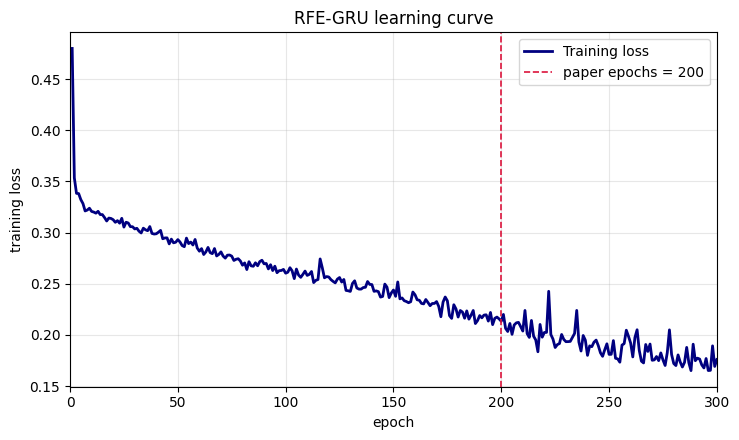

In [5]:
# Train a fresh GRU for 300 epochs only to plot the loss curve 0-300.
CURVE_EPOCHS = 300
MODEL_DIR = os.path.join(os.getcwd(), 'models')
curve_path = os.path.join(MODEL_DIR, 'wine_curve.npy')
if os.path.exists(curve_path):
    loss_history = np.load(curve_path).tolist()
    print(f'Loaded learning curve <- {curve_path}  ({len(loss_history)} epochs)')
elif 'curve_model' in globals() and getattr(curve_model, 'loss_history', None):
    loss_history = list(curve_model.loss_history)   # cache what we already have
    os.makedirs(MODEL_DIR, exist_ok=True)
    np.save(curve_path, np.asarray(loss_history, dtype=np.float64))
    print(f'Saved current learning curve -> {curve_path}  ({len(loss_history)} epochs)')
else:
    torch.manual_seed(42); np.random.seed(42)
    curve_model = FeatureGRU(n_features, n_classes=n_classes, hidden=64).to(device)
    train_nn(curve_model, X_train, y_train, X_test, y_test,
             epochs=CURVE_EPOCHS, lr=0.01, batch_size=32, device=device)
    loss_history = curve_model.loss_history
    os.makedirs(MODEL_DIR, exist_ok=True)
    np.save(curve_path, np.asarray(loss_history, dtype=np.float64))
    print(f'Saved learning curve -> {curve_path}  ({len(loss_history)} epochs)')

epochs_axis = range(1, len(loss_history) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(epochs_axis, loss_history, color='navy', lw=2,
        label='Training loss')
ax.axvline(200, color='crimson', ls='--', lw=1.2,
           label=f'paper epochs = 200')
ax.set_xlim(0, 300); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
ax.set_title('RFE-GRU learning curve')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 3. Build the simplex-tree surrogate

Fill `[0,1]^d` with random points labelled by the GRU, then add the real train points so every class is represented. The simplex tree (LinearSVC head, OvR-multiclass when n_classes>2) is trained on this fill set.

In [6]:
# Fill [0,1]^d with random points labelled by the GRU, then add the real train
# set so every class is represented. The surrogate fits this fill distribution.
N_FILL, C_PARAM = 5000, 10000
np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_pred(X_fill)
X_fill = np.vstack([X_fill, X_train])
y_fill = np.concatenate([y_fill, nn_pred(X_train)])
print(f'Surrogate training points: {len(X_fill)}   '
      f'class counts: {dict(zip(*np.unique(y_fill, return_counts=True)))}')


Surrogate training points: 10197   class counts: {np.int64(0): np.int64(8543), np.int64(1): np.int64(1387), np.int64(2): np.int64(267)}


### Accuracy vs subdivision levels

Sweep the surrogate's `subdivision_levels` and plot the test agreement with the NN and the test accuracy against true labels.

subdivision_levels=1: leaves=     5  agreement-with-NN=0.9115  acc-vs-labels=0.8685


subdivision_levels=2: leaves=    25  agreement-with-NN=0.9254  acc-vs-labels=0.8692


subdivision_levels=3: leaves=   125  agreement-with-NN=0.9154  acc-vs-labels=0.8638


subdivision_levels=4: leaves=   625  agreement-with-NN=0.9077  acc-vs-labels=0.8585


subdivision_levels=5: leaves=  3125  agreement-with-NN=0.8923  acc-vs-labels=0.8515


subdivision_levels=6: leaves= 15625  agreement-with-NN=0.8708  acc-vs-labels=0.8331

Highest agreement with NN at subdivision level 2 (= 0.9254)


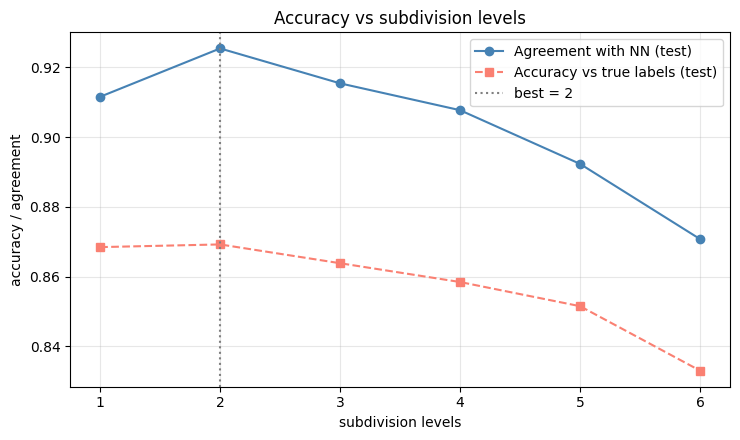

In [7]:
# Sweep subdivision_levels and report (a) surrogate-NN agreement on the test
# set, (b) surrogate accuracy on the true labels.
sub_levels = [1, 2, 3, 4, 5, 6]
agree_with_nn, acc_vs_labels = [], []
y_nn_te = nn_pred(X_test)
for L in sub_levels:
    m = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=L)
    m.fit(X_fill, y_fill)
    agree_with_nn.append(accuracy_score(y_nn_te, m.predict(X_test)))
    acc_vs_labels.append(accuracy_score(y_test, m.predict(X_test)))
    print(f'subdivision_levels={L}: leaves={len(m.leaf_simplexes):6d}  '
          f'agreement-with-NN={agree_with_nn[-1]:.4f}  '
          f'acc-vs-labels={acc_vs_labels[-1]:.4f}')

best_i = int(np.argmax(agree_with_nn))
print(f'\nHighest agreement with NN at subdivision level {sub_levels[best_i]} '
      f'(= {agree_with_nn[best_i]:.4f})')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sub_levels, agree_with_nn, 'o-', color='steelblue',
        label='Agreement with NN (test)')
ax.plot(sub_levels, acc_vs_labels, 's--', color='salmon',
        label='Accuracy vs true labels (test)')
ax.axvline(sub_levels[best_i], color='gray', ls=':',
           label=f'best = {sub_levels[best_i]}')
ax.set_xlabel('subdivision levels')
ax.set_ylabel('accuracy / agreement')
ax.set_title('Accuracy vs subdivision levels')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Initial surrogate at subdivision_levels = 4

Subdivision levels chosen to give a deep enough tree that the surrogate starts to **overfit the fill points** -- exactly the regime where pruning the non-convex leaves should help.

In [8]:
import pickle
SUBDIVISION_LEVELS = 4
# Load the fitted surrogate (before removal) from disk if present; else fit and save it.
STC_PATH = os.path.join(os.getcwd(), 'models', 'wine_stc.pkl')
if os.path.exists(STC_PATH):
    with open(STC_PATH, 'rb') as f:
        stc = pickle.load(f)
    print(f'Loaded stc <- {STC_PATH}')
else:
    stc = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)
    stc.fit(X_fill, y_fill)
    os.makedirs(os.path.dirname(STC_PATH), exist_ok=True)
    with open(STC_PATH, 'wb') as f:
        pickle.dump(stc, f)
    print(f'Saved stc -> {STC_PATH}')
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Agreement (fill) = {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Agreement (test) = {accuracy_score(nn_pred(X_test), stc.predict(X_test)):.4f}')


Loaded stc <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/wine_stc.pkl
Surrogate leaves: 625


Agreement (fill) = 0.8851


Agreement (test) = 0.9077


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus any neighbour for ANY of the OvR hyperplanes. `epsilon` controls strictness (smaller = only severe curvature).

In [9]:
EPSILON = 0.05
crossing = stc.identify_crossing_simplices()
depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
print(f'Boundary-crossing simplices : {len(crossing)}')
print(f'Non-convex simplices        : {len(depths)}  '
      f'({len(depths) / max(len(stc.leaf_simplexes),1):.0%} of leaves, '
      f'epsilon={EPSILON})')

nonconvex_keys = set(depths.keys())
test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 551
Non-convex simplices        : 551  (88% of leaves, epsilon=0.05)


Test points inside a non-convex region: 791 / 1300


## Experiment 1 -- Non-convex removal reduces overfitting

The surrogate copies the GRU from the fill points; with too many leaves it **overfits**. We remove the non-convex simplices (deepest bend first, up to 25% of leaves) and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher = less overfitting}).$$

In [10]:
# Remove non-convex leaves -- deepest bend first, up to 25% of the initial
# leaf count (total budget). Refits after each pass. Cached to disk.
STC_CONVEX_PATH = os.path.join(os.getcwd(), 'models', 'wine_stc_convex.pkl')
def make_model():
    return SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)

if os.path.exists(STC_CONVEX_PATH):
    with open(STC_CONVEX_PATH, 'rb') as f:
        stc_convex = pickle.load(f)
    print(f'Loaded stc_convex <- {STC_CONVEX_PATH}')
else:
    stc_convex = build_convex_surrogate(make_model, X_fill, y_fill,
                                        epsilon=EPSILON,
                                        max_remove_frac=0.25, max_iter=8)
    os.makedirs(os.path.dirname(STC_CONVEX_PATH), exist_ok=True)
    with open(STC_CONVEX_PATH, 'wb') as f:
        pickle.dump(stc_convex, f)
    print(f'Saved stc_convex -> {STC_CONVEX_PATH}')


Loaded stc_convex <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/wine_stc_convex.pkl


In [11]:
y_nn_test = nn_pred(X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))
    return train_agree, test_agree, train_agree - test_agree, test_agree / max(train_agree,1e-9), true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  '
      f'({c_gc - b_gc:+.4f}, {"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  '
      f'({c_acc - b_acc:+.4f})')


                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                                625                  469
Train agreement (vs NN)            0.8851               0.8803
Test  agreement (vs NN)            0.9077               0.9169
Gap (train - test)                -0.0226              -0.0367
Generalisation coef.               1.0256               1.0417
Test accuracy (vs labels)          0.8585               0.8677

Generalisation coefficient: 1.0256 -> 1.0417  (+0.0161, IMPROVED)
Test accuracy vs labels  : 0.8585 -> 0.8677  (+0.0092)


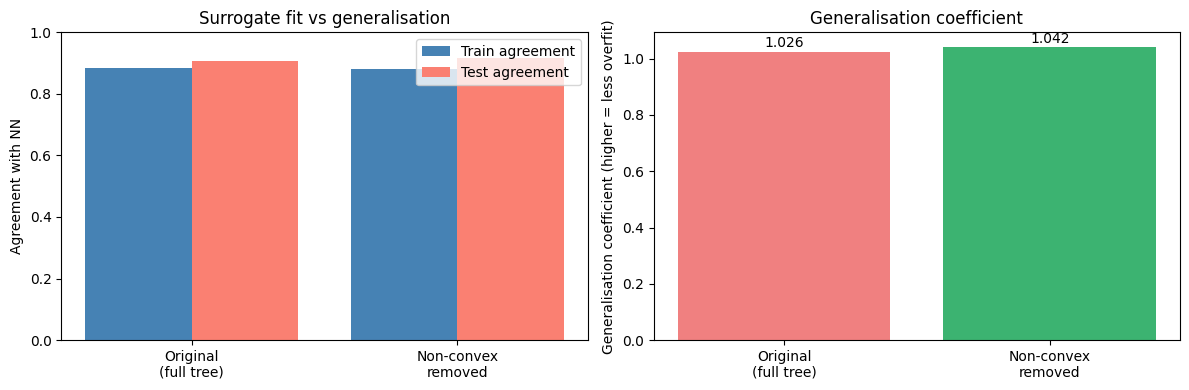

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


### Headline: the pruned surrogate vs the GRU

Same metric (true-label test / train) for both. If removal really cuts overfitting, the pruned surrogate's gen-coef should pass the GRU's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
GRU (network being explained)        0.8974   0.8923     0.9943
Simplex-tree surrogate               0.8611   0.8677     1.0077
----------------------------------------------------------------
Surrogate gen-coef 1.0077  vs  GRU gen-coef 0.9943  -> HIGHER (the surrogate overfits less than the GRU)
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.


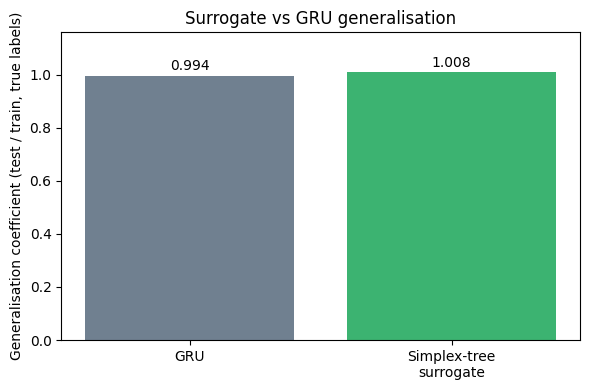

In [13]:
# Same metric (true-label test / train) for both. If pruning really cuts
# overfitting, the pruned surrogate's gen-coef should pass the GRU's.
nn_tr, nn_te, nn_gc = gen_coef(nn_pred, X_train, y_train, X_test, y_test)
p_tr,  p_te,  p_gc  = gen_coef(stc_convex.predict, X_train, y_train, X_test, y_test)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"GRU (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  GRU gen-coef {nn_gc:.4f}  -> '
      f'{"HIGHER (the surrogate overfits less than the GRU)" if p_gc > nn_gc else "lower (NN already generalises well)"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['GRU', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title('Surrogate vs GRU generalisation')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


## Experiment 2 -- LIME is faithful on the pruned surrogate but not on the NN

Take a point $x_0$ in a region where the **NN is non-convex** (found via the simplex tree) and compare
LIME's explanation of the **NN** with LIME's explanation of our **pruned simplex-tree surrogate**
(`stc_convex`, after non-convex removal) at the *same* point. For each model we fit LIME at $x_0$ for
the target class (the class the NN predicts there), read the direction LIME says increases that class,
and step along it while tracking the model's *true* $P(\text{target})$:

- **NN:** LIME claims $P(\text{target})$ only grows, but following that direction the NN's prediction
  **crosses the decision boundary** -- its argmax leaves the target class and $P(\text{target})$
  collapses. LIME's linear explanation is unfaithful here.
- **Pruned surrogate:** at the same point the surrogate is locally convex (the bend was removed), so
  $P(\text{target})$ **rises and the prediction stays in the target class** -- no crossing, LIME is
  faithful.

The **primary quantitative result** (aggregate local fidelity over all non-convex points) follows the
illustration below.

In [14]:
# LIME setup. We explain TWO models at the same point: the NN (being explained)
# and our PRUNED surrogate stc_convex (after non-convex removal). The LIME
# explainer only needs the training distribution, so one explainer serves both;
# the model enters through the proba function passed to lime_direction.
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular

# Fallback class names for notebooks that don't define them (e.g. binary +1/-1).
if 'class_names' not in globals():
    class_names = [str(c) for c in range(n_classes)]

def nn_proba(X_):
    return predict_proba(nn_model, X_, device=device)

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def stc_proba(X_):
    """SMOOTH probabilities for the pruned surrogate: softmax of its one-vs-rest
    decision_function. Smooth (unlike hard labels) so LIME can fit a meaningful
    local linear model and P(target) varies continuously along the path."""
    X_ = np.atleast_2d(np.asarray(X_, dtype=np.float64))
    d = np.asarray(stc_convex.classifier.decision_function(stc_convex.transform(X_)))
    if d.ndim == 1:                      # binary fallback
        d = np.column_stack([-d, d])
    return _softmax(d)

explainer = make_lime_explainer(X_train, feature_names, n_classes=n_classes)
ALPHA = np.linspace(0, 0.15, 61)   # LOCAL step: LIME's linear model is only
#                                    trustworthy near x0, so we compare the two
#                                    models over a short local move, not a long one.

def push(point, proba_fn, target=None):
    """Fit LIME to `proba_fn` at `point`, then step along the direction LIME says
    increases P(target) (target defaults to the model's argmax at the point).
    Returns alphas, P(target), LIME P(target), target, w, unit d, and the model's
    argmax along the whole path (int array)."""
    point = np.asarray(point, dtype=np.float32)
    if target is None:
        target = int(np.argmax(proba_fn(point)[0]))
    # Reset LIME's RNG each call so a point's explanation is REPRODUCIBLE: without
    # this the explainer's RNG advances between cells and the same point yields a
    # different direction in the readout vs the plot.
    explainer.random_state = np.random.RandomState(0)
    coef, _, lime_p_fn, grad = lime_direction(
        explainer, proba_fn, point, target_label=target, num_features=n_features)
    d = grad / max(np.linalg.norm(grad), 1e-12)
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    P = proba_fn(xs)
    return ALPHA, P[:, target], np.clip(lime_p_fn(xs), 0, 1), target, coef, d, np.argmax(P, axis=1)

def crosses_boundary(argmax_path, target):
    """True if the model's argmax LEAVES the target class anywhere on the path
    (i.e. LIME's 'increase target' step actually crosses the decision boundary)."""
    return bool((np.asarray(argmax_path) != target).any())

def first_crossing(argmax_path, target):
    """Index of the first step where the argmax leaves the target class, else None."""
    off = np.where(np.asarray(argmax_path) != target)[0]
    return int(off[0]) if off.size else None

# --- Experiment-2 (v2): does LIME point toward where the target actually gets strong? ---
ANG_MISS, ANG_FIND = 60.0, 45.0    # degrees: NN "misses" ascent if angle>=MISS; surrogate "finds" it if angle<=FIND
# Data-dependent local scale: one unit = one per-feature std of the TRAIN data. Every
# neighborhood/step below is expressed in these units, so it means the same thing on
# every dataset (unlike a hard-coded step in raw [0,1]).
SIGMA = np.asarray(X_train, dtype=np.float64).std(axis=0)
SIGMA = np.where(SIGMA < 1e-6, 1e-6, SIGMA)
R_STD = 1.0                         # heatmap half-window, in std units (dimensionless)

def target_grad(proba_fn, x0, target, h=2e-2):
    """Numerical gradient of P(target) at x0 -- the LOCAL steepest-ascent direction of the
    target probability (central differences, clipped to the [0,1] box)."""
    x0 = np.asarray(x0, dtype=np.float64)
    g = np.zeros_like(x0)
    for k in range(x0.size):
        xp = x0.copy(); xm = x0.copy()
        xp[k] = min(1.0, x0[k] + h); xm[k] = max(0.0, x0[k] - h)
        dk = xp[k] - xm[k]
        g[k] = (proba_fn(xp[None])[0, target] - proba_fn(xm[None])[0, target]) / (dk if dk > 0 else 1.0)
    return g

def angle_deg(a, b):
    """Angle (degrees) between two vectors."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a / max(np.linalg.norm(a), 1e-12); b = b / max(np.linalg.norm(b), 1e-12)
    return float(np.degrees(np.arccos(np.clip(a @ b, -1.0, 1.0))))

def lime_unit(proba_fn, x0, target):
    """Unit vector of LIME's 'increase P(target)' direction at x0 (as push uses)."""
    _, _, _, _, _, d, _ = push(np.asarray(x0, np.float32), proba_fn, target=target)
    return d

def _slice_basis(d_lime, g):
    """Orthonormal basis (u, v) of the plane through the target-ascent u=g/|g| and LIME's
    direction (which then lies in span(u, v))."""
    u = np.asarray(g, float); u = u / max(np.linalg.norm(u), 1e-12)
    w = d_lime - (d_lime @ u) * u
    nw = np.linalg.norm(w)
    if nw < 1e-9:                       # LIME parallel to ascent: pick any orthogonal axis
        e = np.zeros_like(u); e[int(np.argmin(np.abs(u)))] = 1.0
        w = e - (e @ u) * u; nw = np.linalg.norm(w)
    return u, w / nw

def local_fidelity(proba_fn, x0, target, sigma=None, h=0.25, m=600, seed=0, ridge=1e-6):
    """LIME's essence, as a knob-light number: fit a local LINEAR model of P(target) in a
    sigma-scaled neighborhood of x0 (radius h*sigma per feature -- data-dependent, only the
    dimensionless h is chosen) and return its R^2 = LIME's local fidelity. Low R^2 means a
    linear explanation CANNOT represent the local behavior (a non-convex region). Also
    returns the local std of P(target) (to skip flat regions where R^2 is ill-defined)."""
    if sigma is None:
        sigma = SIGMA
    r = np.random.default_rng(seed)
    x0 = np.asarray(x0, dtype=np.float64)
    Xs = np.clip(x0 + r.normal(0, 1, size=(m, x0.size)) * (h * np.asarray(sigma)), 0, 1)
    y = np.asarray(proba_fn(Xs))[:, target]
    A = np.column_stack([np.ones(m), Xs - x0])
    coef = np.linalg.solve(A.T @ A + ridge * np.eye(A.shape[1]), A.T @ y)
    yhat = A @ coef
    ss_res = float(np.sum((y - yhat) ** 2)); ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-10 else 1.0
    return float(np.clip(r2, 0.0, 1.0)), float(y.std())

def target_slice(ax, proba_fn, x0, target, R=None, n=61, arrow=0.85):
    """2D slice of P(target) around x0 in the plane spanned by LIME's direction and the true
    target-ascent grad P(target). Window is sigma-scaled (R std units). Crimson arrow = LIME,
    blue arrow = ascent. Returns (angle between LIME and ascent [deg], P(target) at x0, image)."""
    if R is None:
        R = R_STD * float(np.mean(SIGMA))          # data-dependent half-window (feature units)
    x0 = np.asarray(x0, dtype=np.float64)
    d_lime = lime_unit(proba_fn, x0, target)
    g = target_grad(proba_fn, x0, target)
    u, v = _slice_basis(d_lime, g)
    ss = np.linspace(-R, R, n); ts = np.linspace(-R, R, n)
    S, T = np.meshgrid(ss, ts)
    pts = np.clip(x0[None, :] + S.ravel()[:, None] * u[None, :] + T.ravel()[:, None] * v[None, :], 0, 1)
    P = proba_fn(pts)[:, target].reshape(n, n)
    im = ax.pcolormesh(S, T, P, cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.contour(S, T, P, levels=[0.5], colors='white', linewidths=1.2, linestyles='--')
    la = np.array([d_lime @ u, d_lime @ v]); la = la / max(np.linalg.norm(la), 1e-12)
    ax.annotate('', xy=(R * arrow, 0), xytext=(0, 0),
                arrowprops=dict(color='deepskyblue', width=2.5, headwidth=9))
    ax.annotate('', xy=(la[0] * R * arrow, la[1] * R * arrow), xytext=(0, 0),
                arrowprops=dict(color='crimson', width=2.5, headwidth=9))
    ax.scatter([0], [0], color='white', edgecolor='black', zorder=6, s=45)
    ax.set_xlim(-R, R); ax.set_ylim(-R, R); ax.set_aspect('equal')
    return angle_deg(d_lime, g), float(proba_fn(x0[None])[0, target]), im


In [15]:
# Find the demo point. We want an area that is NON-CONVEX in the NN's simplex-tree
# approximation (`stc`) but became CONVEX in the pruned surrogate `stc_convex` (its
# split was removed). For each candidate we fit LIME on BOTH models (same target =
# the NN's class at x0) and check whether the NN CROSSES the decision boundary along
# ITS LIME direction (P(target) collapses) while the pruned surrogate STAYS in the
# target class along ITS LIME direction.
# (robustness) recompute the non-convex info if the "### 4. Find non-convex
# regions" cell above was not run in this kernel session.
if 'EPSILON' not in globals():
    EPSILON = 0.05
if 'depths' not in globals():
    depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
if 'nonconvex_keys' not in globals():
    nonconvex_keys = set(depths.keys())

test_depths = np.array([
    depths.get(leaf_key_for_point(stc, x), 0.0) for x in X_test])
print(f'test-point depth: min={test_depths.min():.4f}  '
      f'median={np.median(test_depths):.4f}  max={test_depths.max():.4f}')
if (test_depths > 0).any():
    nz_med = float(np.median(test_depths[test_depths > 0]))
    nc_pool = np.where(test_depths >= nz_med)[0]     # strongly bent (NN non-convex)
else:
    nc_pool = np.arange(len(X_test))
print(f'non-convex pool (depth>=median nonzero): {len(nc_pool)}')

# Which regions are still non-convex AFTER pruning? A demo point should sit in a
# leaf that WAS non-convex in `stc` and is now convex in `stc_convex`.
depths_convex = find_nonconvex_leaves(stc_convex, epsilon=EPSILON)
nonconvex_keys_convex = set(depths_convex)
print(f'non-convex leaves: original stc={len(nonconvex_keys)}  '
      f'pruned stc_convex={len(nonconvex_keys_convex)}')

rng = np.random.default_rng(0)
BUDGET = 200                       # LIME is slow and we fit it twice per point
cand = nc_pool if len(nc_pool) <= BUDGET else rng.choice(nc_pool, BUDGET, replace=False)

rows = []
for i in cand:
    x0 = X_test[int(i)]
    try:
        _, f_nn, _, target, _, _, am_nn = push(x0, nn_proba)
    except Exception:
        continue
    try:
        _, f_st, _, _, _, _, am_st = push(x0, stc_proba, target=target)
    except Exception:
        f_st, am_st = None, None
    nn_cross = crosses_boundary(am_nn, target)
    nn_dip   = float(f_nn.min())                     # deepest P(target) on the NN path
    stc_stay   = (am_st is not None) and (not crosses_boundary(am_st, target))
    stc_agrees = (f_st is not None) and (float(f_st[0]) >= 0.5)   # surrogate agrees with NN at x0: P(target) >= 0.5
    stc_rise = float(f_st[-1] - f_st[0]) if f_st is not None else float('nan')
    was_nc   = leaf_key_for_point(stc, x0) in nonconvex_keys
    now_cvx  = leaf_key_for_point(stc_convex, x0) not in nonconvex_keys_convex
    rows.append(dict(i=int(i), target=int(target), nn_cross=nn_cross, nn_dip=nn_dip,
                     nn_start=float(f_nn[0]), stc_stay=stc_stay, stc_agrees=stc_agrees, stc_rise=stc_rise,
                     made_convex=(was_nc and now_cvx)))

print(f'candidates evaluated: {len(rows)}   '
      f'(became convex after removal: {sum(r["made_convex"] for r in rows)})')
# Breakdown of why candidates pass/fail (useful when demo_idx ends up None).
print(f'  NN crosses={sum(r["nn_cross"] for r in rows)}  '
      f'surrogate agrees@x0 (P>=.5)={sum(r["stc_agrees"] for r in rows)}  '
      f'surrogate stays={sum(r["stc_stay"] for r in rows)}')
print(f'  NN-cross & agrees={sum(r["nn_cross"] and r["stc_agrees"] for r in rows)}  '
      f'NN-cross & agrees & stays (tier1)={sum(r["nn_cross"] and r["stc_agrees"] and r["stc_stay"] for r in rows)}')

# Accept a demo point ONLY if the surrogate AGREES with the NN at x0 (start P(target) >= 0.5)
# and STAYS in the target class along its own LIME direction, while the NN CROSSES the boundary.
# tier0 additionally confirms the area was non-convex in the NN and became convex after pruning.
# Prefer a demo where x0 starts CLEARLY inside the target class (not right on the
# boundary) so the failure is unambiguous: NN begins in the class, then LIME's own
# direction drives it across. Rank by the deepest NN dip.
STRONG_START = 0.60
tier0 = [r for r in rows if r['nn_cross'] and r['stc_stay'] and r['stc_agrees'] and r['made_convex']]
tier1 = [r for r in rows if r['nn_cross'] and r['stc_stay'] and r['stc_agrees']]
tier0c = [r for r in tier0 if r['nn_start'] >= STRONG_START]
tier1c = [r for r in tier1 if r['nn_start'] >= STRONG_START]
if tier0c:
    demo, kind = min(tier0c, key=lambda r: r['nn_dip']), 'non-convex->convex, x0 clearly in class, NN crosses, surrogate faithful'
elif tier1c:
    demo, kind = min(tier1c, key=lambda r: r['nn_dip']), 'x0 clearly in class, NN crosses along its LIME dir, surrogate faithful'
elif tier0:
    demo, kind = min(tier0, key=lambda r: r['nn_dip']), 'non-convex->convex, NN crosses, surrogate faithful (x0 near boundary)'
elif tier1:
    demo, kind = min(tier1, key=lambda r: r['nn_dip']), 'NN crosses + surrogate faithful (x0 near boundary)'
else:
    demo, kind = None, 'none'
    print('NOTE: no point where the surrogate agrees with the NN at x0 (P(target)>=0.5) '
          'and stays faithful while the NN crosses. Nothing to plot -- try a larger '
          'BUDGET or a lower SUBDIVISION_LEVELS.')

demo_idx = demo['i'] if demo else None
print(f'Demo point: idx {demo_idx}   ({kind})')

test-point depth: min=0.0000  median=0.0081  max=0.0425
non-convex pool (depth>=median nonzero): 436


non-convex leaves: original stc=551  pruned stc_convex=331


candidates evaluated: 200   (became convex after removal: 2)
  NN crosses=55  surrogate agrees@x0 (P>=.5)=134  surrogate stays=125
  NN-cross & agrees=14  NN-cross & agrees & stays (tier1)=8
Demo point: idx 915   (x0 clearly in class, NN crosses along its LIME dir, surrogate faithful)


In [16]:
# Detailed readout at the demo point. First confirm the geometry: the area is
# non-convex in the NN's tree (`stc`) and convex in the pruned surrogate
# (`stc_convex`) because its split was removed. Then fit LIME on each model,
# follow its own LIME direction, and report whether the prediction crosses the
# decision boundary (P(target) collapses) or stays inside the target class.
if demo_idx is None:
    print('Skipping detailed report -- no demo point.')
else:
    x0 = X_test[demo_idx].astype(np.float32)
    was_nc  = leaf_key_for_point(stc, x0) in nonconvex_keys
    now_cvx = leaf_key_for_point(stc_convex, x0) not in nonconvex_keys_convex
    print(f'Region at x0:  non-convex in NN tree = {was_nc}   '
          f'convex in pruned surrogate = {now_cvx}')
    print(f'  (i.e. the simplex-tree removed the split that made this area non-convex)\n')

    a, f_nn, g_nn, target, w_nn, d_nn, am_nn = push(x0, nn_proba)
    _, f_st, g_st, _,      w_st, d_st, am_st = push(x0, stc_proba, target=target)
    xc = first_crossing(am_nn, target)
    a_dip = int(np.argmin(f_nn))
    other = int(am_nn[a_dip])

    np.set_printoptions(precision=4, suppress=True, sign='+')
    print(f'target class (NN argmax at x0) = {target} ({class_names[target]})')
    print(f'LIME weights on NN        w = {w_nn}')
    print(f'LIME weights on surrogate w = {w_st}')
    print()
    print(f'NN   P(target) : start {f_nn[0]:.3f}  ->  min {f_nn[a_dip]:.3f}  ->  end {f_nn[-1]:.3f}')
    print(f'  NN argmax leaves target at step alpha={a[xc]:.3f} (-> {class_names[other]})'
          if xc is not None else '  NN argmax never leaves the target class')
    print(f'  NN crosses the decision boundary: {crosses_boundary(am_nn, target)}')
    print()
    print(f'STC  P(target) : start {f_st[0]:.3f}  ->  end {f_st[-1]:.3f}  '
          f'(change {f_st[-1] - f_st[0]:+.3f})')
    print(f'  Surrogate stays in the target class: {not crosses_boundary(am_st, target)}')

    if crosses_boundary(am_nn, target) and not crosses_boundary(am_st, target):
        print()
        print(f"=> This area is non-convex in the NN and convex in our surrogate. Along "
              f"LIME's own direction the NN wrongly crosses into {class_names[other]} and "
              f"P(target) collapses ({f_nn[0]:.2f} -> {f_nn[a_dip]:.2f}) -- LIME misreads the "
              f"NN. On the pruned surrogate the prediction never leaves {class_names[target]} "
              f"and P(target) rises ({f_st[0]:.2f} -> {f_st[-1]:.2f}) -- LIME is faithful. "
              f"Removing the split bought a locally faithful explanation.")
    else:
        print()
        print('=> NOTE: the clean NN-crosses / surrogate-stays contrast did not occur at '
              'this point on this run; see the selection tiers above.')

Region at x0:  non-convex in NN tree = True   convex in pruned surrogate = False
  (i.e. the simplex-tree removed the split that made this area non-convex)

target class (NN argmax at x0) = 0 (0)
LIME weights on NN        w = [+0.1656 -0.0429 -0.0056 -0.0688]
LIME weights on surrogate w = [+0.1268 -0.0119 -0.0205 -0.0367]

NN   P(target) : start 1.000  ->  min 0.094  ->  end 1.000
  NN argmax leaves target at step alpha=0.070 (-> 1)
  NN crosses the decision boundary: True

STC  P(target) : start 0.802  ->  end 0.849  (change +0.046)
  Surrogate stays in the target class: True

=> This area is non-convex in the NN and convex in our surrogate. Along LIME's own direction the NN wrongly crosses into 1 and P(target) collapses (1.00 -> 0.09) -- LIME misreads the NN. On the pruned surrogate the prediction never leaves 0 and P(target) rises (0.80 -> 0.85) -- LIME is faithful. Removing the split bought a locally faithful explanation.


### LIME on the NN vs LIME on the pruned surrogate (same point)

Both panels start at the **same** non-convex point $x_0$ and step along the direction *that model's own*
LIME explanation says increases the target class, plotting the model's true $P(\text{target})$.
**Left (NN):** LIME promises $P(\text{target})$ will rise, but it **collapses** and the argmax
**crosses the decision boundary** (the shaded band marks the steps outside the target class), so the
linear LIME model misrepresents the NN. **Right (pruned surrogate):** at the same point the surrogate
is locally convex, so $P(\text{target})$ **rises and the prediction stays in the target class** -- no
crossing, LIME is faithful. Titles are set from the actual curves; if the clean contrast does not occur
on this run it is reported honestly.

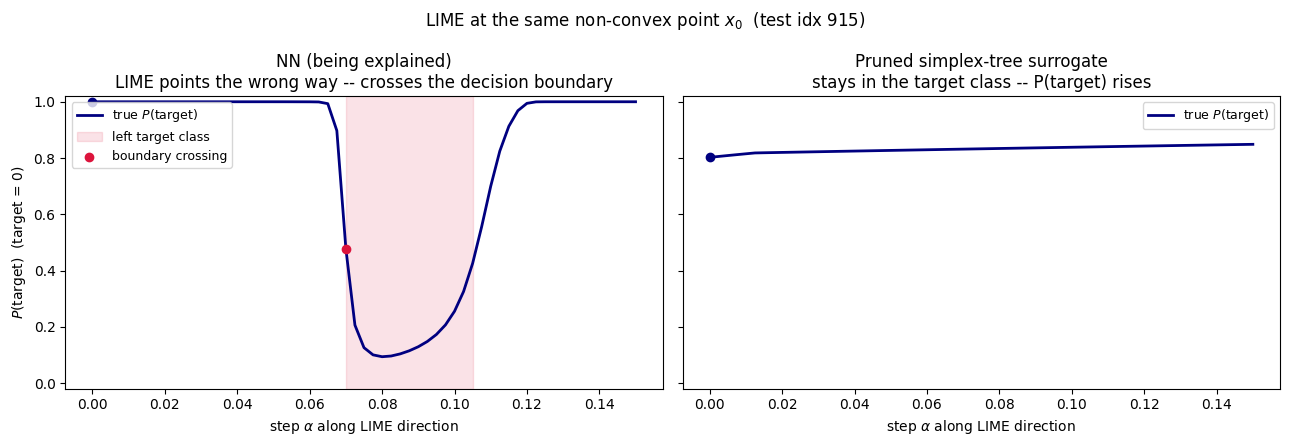

model                            start     min     end   verdict
----------------------------------------------------------------
NN (being explained)             1.000   0.094   1.000   CROSSES boundary (LIME unfaithful)
Pruned simplex-tree surrogate    0.802   0.802   0.849   stays (LIME faithful)


In [17]:
if demo_idx is None:
    print('No demo point to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    x0 = X_test[demo_idx].astype(np.float32)
    target = int(np.argmax(nn_proba(x0)[0]))
    specs = [('NN (being explained)',          nn_proba, axes[0]),
             ('Pruned simplex-tree surrogate', stc_proba, axes[1])]
    summary = []
    for name, proba_fn, ax in specs:
        a, f_t, g_t, tgt, _, _, am = push(x0, proba_fn, target=target)
        crossed = crosses_boundary(am, target)
        xc = first_crossing(am, target)
        title = (f'{name}\nLIME points the wrong way -- crosses the decision boundary'
                 if crossed else f'{name}\nstays in the target class -- P(target) rises')
        ax.plot(a, f_t, color='navy', lw=2, label=r'true $P(\mathrm{target})$')
        off_mask = np.asarray(am) != target
        if off_mask.any():
            ax.fill_between(a, 0, 1, where=off_mask, color='crimson', alpha=0.12,
                            transform=ax.get_xaxis_transform(), label='left target class')
        ax.scatter([0], [f_t[0]], color='navy', zorder=5)
        if xc is not None:
            ax.scatter([a[xc]], [f_t[xc]], color='crimson', zorder=6, label='boundary crossing')
        ax.set_xlabel(r'step $\alpha$ along LIME direction')
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(title); ax.legend(loc='best', fontsize=9)
        summary.append((name, float(f_t[0]), float(f_t.min()), float(f_t[-1]), crossed))
    axes[0].set_ylabel(r'$P(\mathrm{target})$' + f'  (target = {class_names[target]})')
    plt.suptitle(f'LIME at the same non-convex point $x_0$  (test idx {demo_idx})')
    plt.tight_layout(); plt.show()

    hdr = f'{"model":30s} {"start":>7s} {"min":>7s} {"end":>7s}   verdict'
    print(hdr)
    print('-' * len(hdr))
    for name, s, mn, e, crossed in summary:
        verdict = 'CROSSES boundary (LIME unfaithful)' if crossed else 'stays (LIME faithful)'
        print(f'{name:30s} {s:>7.3f} {mn:>7.3f} {e:>7.3f}   {verdict}')

### Primary result: LIME's local fidelity over ALL non-convex points (NN vs pruned surrogate)

The heatmap above is one illustrative point. The quantitative claim is aggregate and uses **LIME's
own promise -- local fidelity** with no arbitrary step or threshold. At every test point that lies in
a **non-convex** leaf we fit a local *linear* model of $P(\text{target})$ in a $\sigma$-scaled
neighborhood (the quantity LIME optimises) and record its $R^2$:

- a **linear** explanation cannot fit a **non-convex** region, so $R^2$ is **low on the NN**;
- after pruning the region is locally **convex**, so $R^2$ is **high on the pruned surrogate**.

We report the paired distribution (boxplot + paired scatter) with a Wilcoxon signed-rank test, and --
where a continuous non-convexity depth is available -- fidelity vs. that depth. This is the honest,
knob-free version of "LIME misses where the target gets strong": it is measured over all non-convex
points, not a single hand-picked one.

non-convex points with local target variation: 300
NN  local fidelity R^2 : median=0.348  mean=0.359
STC local fidelity R^2 : median=0.572  mean=0.588
surrogate more faithful at 233/300 points
Wilcoxon (surrogate > NN): stat=38621.0  p=6.98e-27


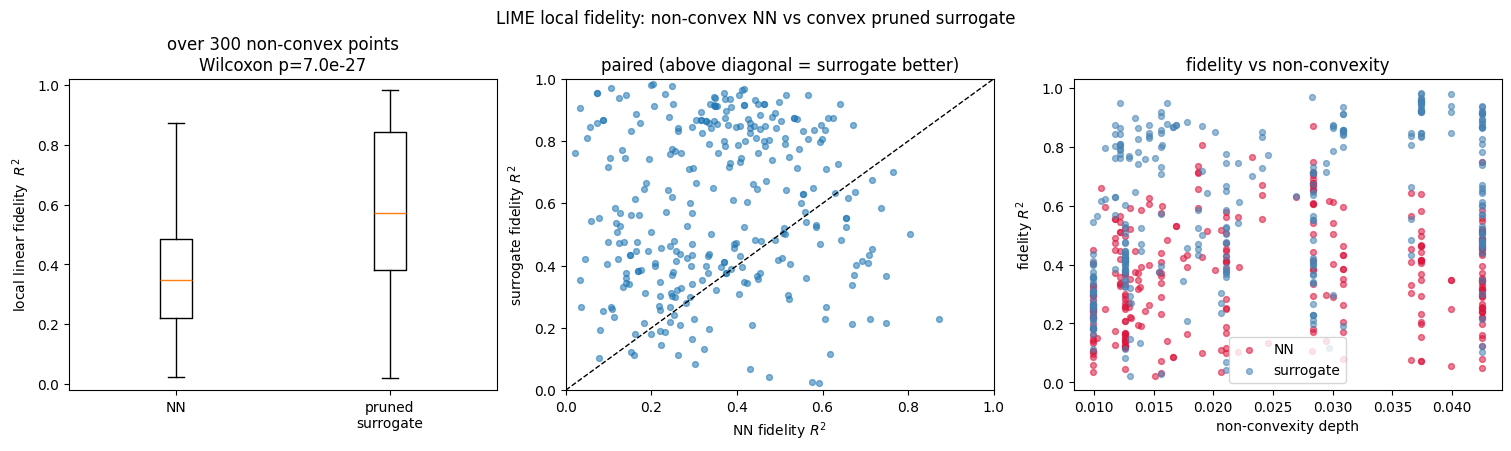

In [18]:
# PRIMARY RESULT: local linear fidelity R^2 of P(target) (the quantity LIME optimises) over
# ALL non-convex test points, NN vs pruned surrogate. No arbitrary step/threshold; the
# neighborhood scale is sigma-based (data-dependent). local_fidelity needs no LIME package,
# so this runs fast over the whole pool.
from scipy.stats import wilcoxon
pool = nc_pool if 'nc_pool' in globals() else np.arange(len(X_test))
if len(pool) > 300:
    pool = np.random.default_rng(0).choice(pool, 300, replace=False)

rows_fid = []
for i in pool:
    x0 = X_test[int(i)]
    target = int(np.argmax(nn_proba(np.asarray(x0, np.float32)[None])[0]))
    r_nn, s_nn = local_fidelity(nn_proba, x0, target)
    r_st, _    = local_fidelity(stc_proba, x0, target)
    if s_nn > 1e-3:                      # only where P(target) actually varies locally
        rows_fid.append((int(i), target, r_nn, r_st))

print(f'non-convex points with local target variation: {len(rows_fid)}')
if not rows_fid:
    print('Nothing to aggregate (P(target) is locally flat at these points).')
else:
    nn_f = np.array([r[2] for r in rows_fid]); st_f = np.array([r[3] for r in rows_fid])
    print(f'NN  local fidelity R^2 : median={np.median(nn_f):.3f}  mean={nn_f.mean():.3f}')
    print(f'STC local fidelity R^2 : median={np.median(st_f):.3f}  mean={st_f.mean():.3f}')
    print(f'surrogate more faithful at {int((st_f > nn_f).sum())}/{len(rows_fid)} points')
    try:
        stat, pval = wilcoxon(st_f, nn_f, alternative='greater')
        print(f'Wilcoxon (surrogate > NN): stat={stat:.1f}  p={pval:.2e}')
    except ValueError:
        pval = float('nan'); print('Wilcoxon: undefined (zero/identical differences)')

    have_depth = 'depths' in globals()
    npan = 3 if have_depth else 2
    fig, ax = plt.subplots(1, npan, figsize=(5 * npan, 4.4), constrained_layout=True)
    ax[0].boxplot([nn_f, st_f], labels=['NN', 'pruned\nsurrogate'])
    ax[0].set_ylabel('local linear fidelity  $R^2$'); ax[0].set_ylim(-0.02, 1.02)
    ax[0].set_title(f'over {len(rows_fid)} non-convex points\nWilcoxon p={pval:.1e}')
    ax[1].scatter(nn_f, st_f, s=18, alpha=0.55); ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
    ax[1].set_xlabel('NN fidelity $R^2$'); ax[1].set_ylabel('surrogate fidelity $R^2$')
    ax[1].set_xlim(0, 1); ax[1].set_ylim(0, 1)
    ax[1].set_title('paired (above diagonal = surrogate better)')
    if have_depth:
        dep = np.array([depths.get(leaf_key_for_point(stc, X_test[int(r[0])]), 0.0) for r in rows_fid])
        ax[2].scatter(dep, nn_f, s=18, color='crimson', alpha=0.55, label='NN')
        ax[2].scatter(dep, st_f, s=18, color='steelblue', alpha=0.55, label='surrogate')
        ax[2].set_xlabel('non-convexity depth'); ax[2].set_ylabel('fidelity $R^2$')
        ax[2].set_title('fidelity vs non-convexity'); ax[2].legend()
    fig.suptitle('LIME local fidelity: non-convex NN vs convex pruned surrogate')
    plt.show()